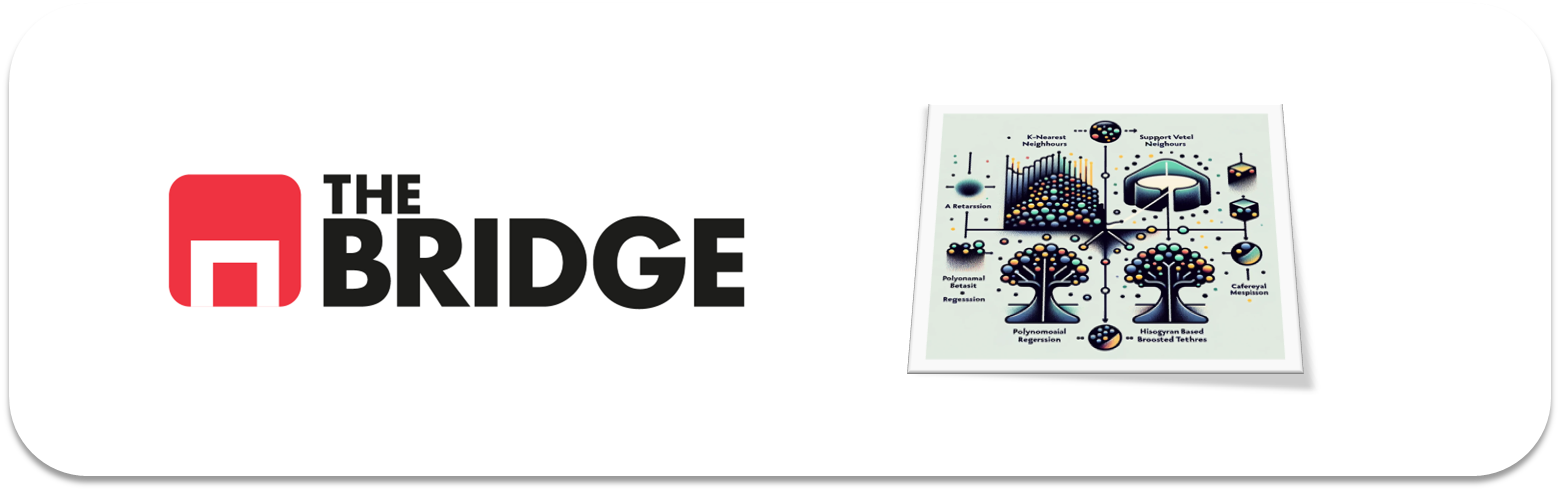

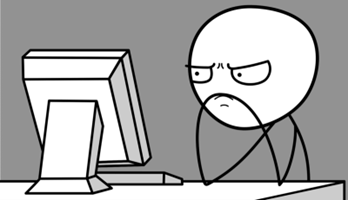

Para hacer un **repaso a los problemas de clasificacion con ML**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### INTRODUCCIóN: PROCESO DE ML

En los siguientes ejercicios vamos a seguir (de nuevo) los pasos básicos en la creación de un modelo de ML para resolver un problema de predicción a partir de un dataset que incluye el target, es decir, un aprendizaje supervisado.

En concreto, vamos a trabajar sobre un problema de clasificación a través de los siguientes pasos:

1. Entendimiento del problema (selección de la métrica más adecuada)  
2. Obtención de datos y primer contacto  
3. Train y Test  
4. MiniEDA: Análisis del target, análisis bivariante, entendimiento de las features, selección de las mismas (si es necesario)  
5. Preparación del dataset de Train: Conversión de categóricas, tratamiento de numéricas  
6. Selección e instanciación de modelos. Baseline.
7. Comparación de modelos (lo haremos por comparación con validación, puedes hacerlo por comparación de modelos de hiperparámetros optimizados, si así lo prefieres)  
8. Selección de modelo: Optimización de hiperparámetros (ten en cuenta la nota de 7)  
9. Equilibrado del train set  
10. Evaluación contra test.  
11. Análisis de errores, posibles acciones futuras.  
12. EXTRA: Persistencia del modelo en disco.  

### El problema

La unidad oncológica del hospital de Madison, Wisconsin, está trabajando en un tratamiento muy prometedor sobre el cáncer de mama. Desgraciadamente es un tratamiento con efectos secundarios y todavía excesivamente caro, pero cuya efectividad es extraordinaria si se aplica en las primeras etapas o incluso antes de haberlo desarrollado. 

En este sentido, la universidad quiere disponer de un modelo que le permita detectar potenciales pacientes pero con un alto nivel de acierto en detectar quien puede tener cáncer para no aplicar el tratamiento a personas que no fueran a desarrollarlo y por tanto no sólo perder dinero, sino también, y más importante causar problemas a esas personas. 

Nos piden trabajar sobre datos que ya tienen, y que pueden obtener facilmente de cualquier futuro aspirante a las pruebas y ensayos con el tratamiento, de pacientes que desarrollaron y no el cáncer. Sobre ese dataset quieren que les proporcionemos el mejor modelo de predicción de quién desarrollará o no el cáncer y que cumpla con las expectativas del párrafo anterior.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import bootcampviztools as bt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import toolbox_ML as tool 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Ejercicio 1: Entendiendo el problema de "Negocio"

En función de la descripción del problema de "negocio" y sin mirar todavía los datos, ¿qué tipo de problema de clasificación vamos a resolver? ¿Qué métricas crees más conveniente para medir el rendimiento del modelo a construir y, por tanto, para comparar posibles modelos entre sí?

In [3]:
from sklearn.metrics import get_scorer_names
print(sorted(get_scorer_names()))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

"Alto nivel de acierto en detectar quien puede desarrollar el cancer" Es un problema de clasificación binaría.    
Para comparar modelos cross_val_score.  
scoring para los modelos: "balanced_accuracy", "recall", "f1".  
(scorers =["balanced_accuracy", "recall", "f1"]). Los resultados estarán en results con claves como 'test_balanced_accuracy', 'test_recall', etc.  
Métricas a utilizar classification_report y confusion_matrix.


### Ejercicio 2: Obtención y primer "vistazo"

Carga el dataset, muestra sus primeras filas, su descripción general y determina el tipo de variables que vamos a manejar. Escoge el target y crea una variable `target` y asignalé el nombre de la columna correspondiente.

In [4]:
df = pd.read_csv("./data/wisconsin_cancer.csv", sep="|")
df.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
 11  radius_se               569 non-null    float64
 12  texture_se              569 non-null    float64
 13  perimeter_se            569 non-null    float64
 14  area_se                 569 non-null    fl

In [6]:
print(tool.describe_df(df))

                         data_type valores_nulos valores_unicos  \
diagnosis               categorica           0.0              2   
radius_mean               numerica           0.0            456   
texture_mean              numerica           0.0            479   
perimeter_mean            numerica           0.0            522   
area_mean                 numerica           0.0            539   
smoothness_mean           numerica           0.0            474   
compactness_mean          numerica           0.0            537   
concavity_mean            numerica           0.0            537   
concave points_mean       numerica           0.0            542   
symmetry_mean             numerica           0.0            432   
fractal_dimension_mean    numerica           0.0            499   
radius_se                 numerica           0.0            540   
texture_se                numerica           0.0            519   
perimeter_se              numerica           0.0            53

In [7]:
print(tool.tipifica_variables(df,umbral_categoria=10, umbral_continua=0.2))

           nombre_variable      tipo_sugerido
0                diagnosis            Binaria
1              radius_mean  Numerica Continua
2             texture_mean  Numerica Continua
3           perimeter_mean  Numerica Continua
4                area_mean  Numerica Continua
5          smoothness_mean  Numerica Continua
6         compactness_mean  Numerica Continua
7           concavity_mean  Numerica Continua
8      concave points_mean  Numerica Continua
9            symmetry_mean  Numerica Continua
10  fractal_dimension_mean  Numerica Continua
11               radius_se  Numerica Continua
12              texture_se  Numerica Continua
13            perimeter_se  Numerica Continua
14                 area_se  Numerica Continua
15           smoothness_se  Numerica Continua
16          compactness_se  Numerica Continua
17            concavity_se  Numerica Continua
18       concave points_se  Numerica Continua
19             symmetry_se  Numerica Continua
20    fractal_dimension_se  Numeri

In [8]:
target =["diagnosis"]
# Diagnosis (M = malignant, B = benign) PRIORIDAD EN DETECTAR LOS MALIGNOS.

NOTA: Para más información sobre el dataset el hospital nos redirige a esta [página web](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download)

### Ejercicio 3: Split

Haz el split en train y test.

In [9]:
train_set, test_set = train_test_split(df, test_size=0.2, stratify= df["diagnosis"], random_state=42)

# En stratify tiene que ir un array, en este caso la columna del df, NO "diagnosis" sin los corchetes.

In [10]:
print(train_set.shape)
print(test_set.shape)

(455, 26)
(114, 26)


### Ejercicio 4: MiniEDA (I)

Analiza la distribución frecuencial de target brevemente.

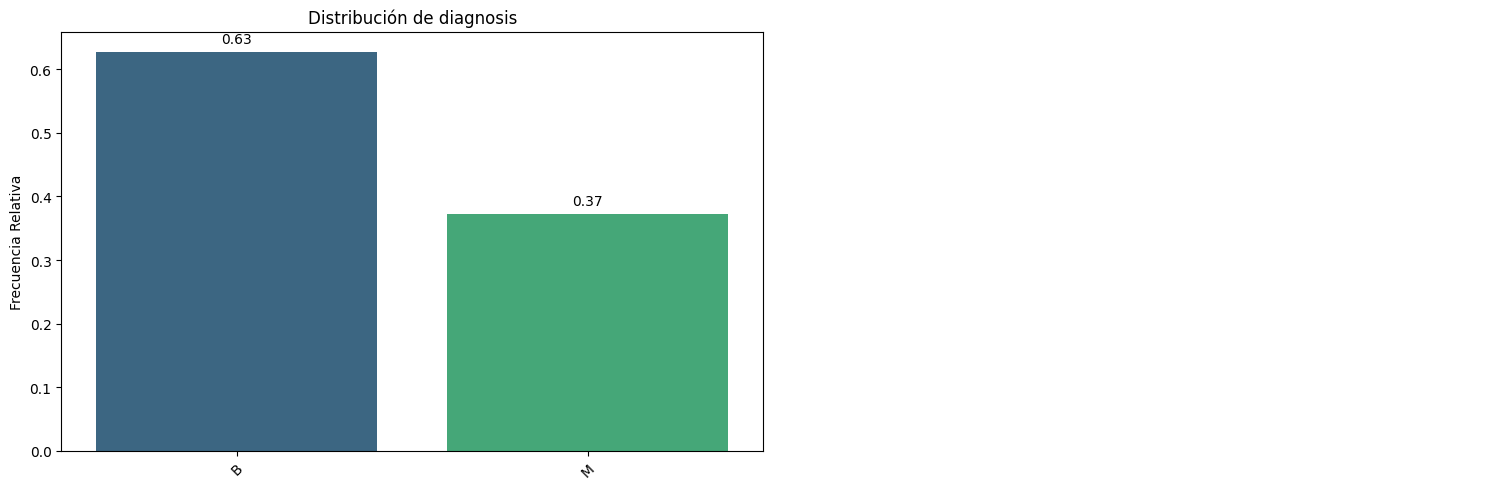

In [11]:
bt.pinta_distribucion_categoricas(df, ["diagnosis"], relativa= True, mostrar_valores= True)

Está desequilibrado en una proporción de dos benignos por un maligno, en este caso la posibilidad en la que más interesados estamos esta en desventaja. (Por ello he usado stratify= en el split)

In [12]:
print(train_set["diagnosis"].value_counts())
print(test_set["diagnosis"].value_counts())

diagnosis
B    285
M    170
Name: count, dtype: int64
diagnosis
B    72
M    42
Name: count, dtype: int64


### Ejercicio 5: MiniEDA (II)

Analiza bivariantemente las variables contra el target, de forma que veamos las distintas distribuciones para cada clase (puedes emplear la librería gráfica que crees conveniente)

In [13]:
train_copi = train_set.drop("diagnosis", axis=1)

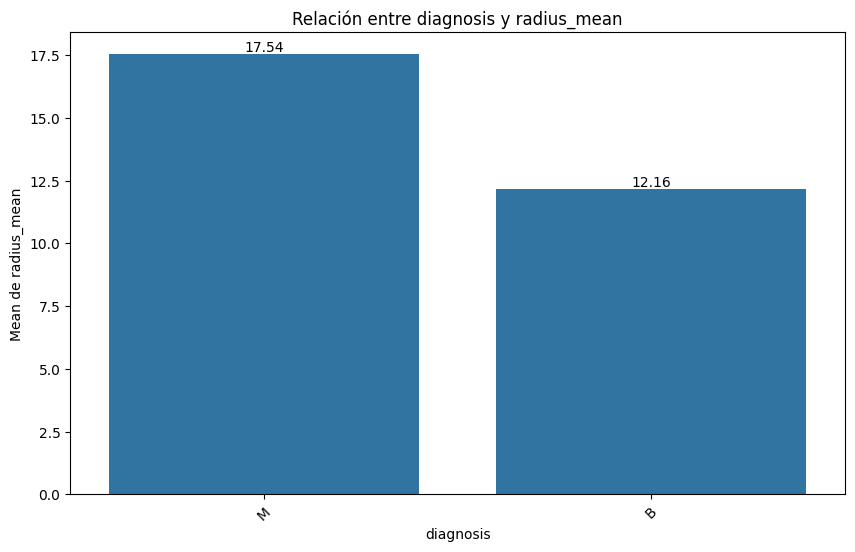

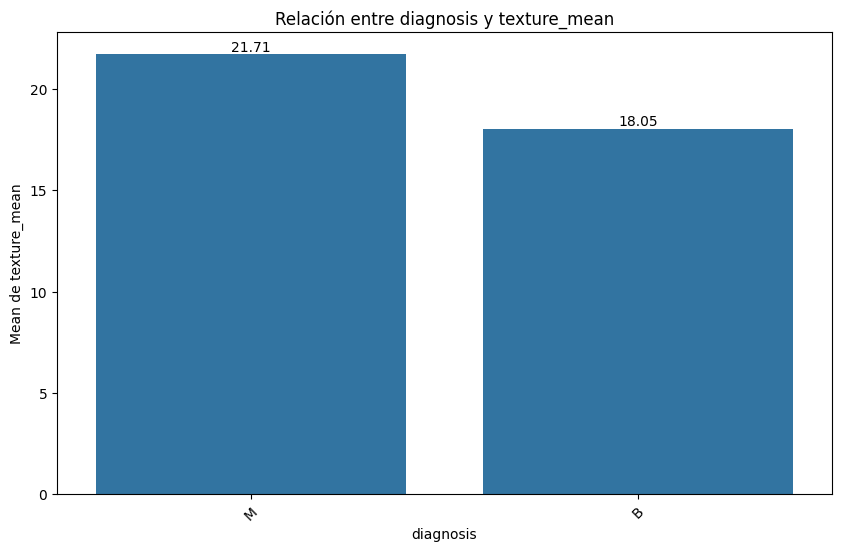

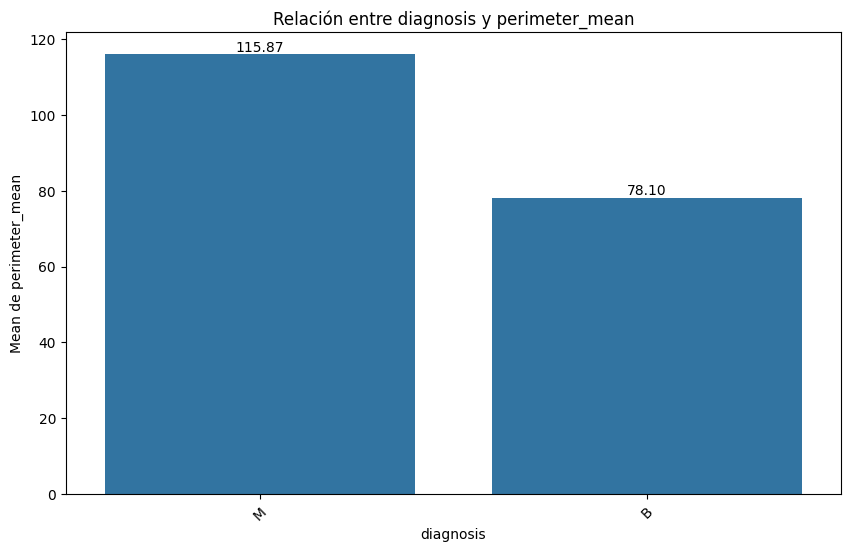

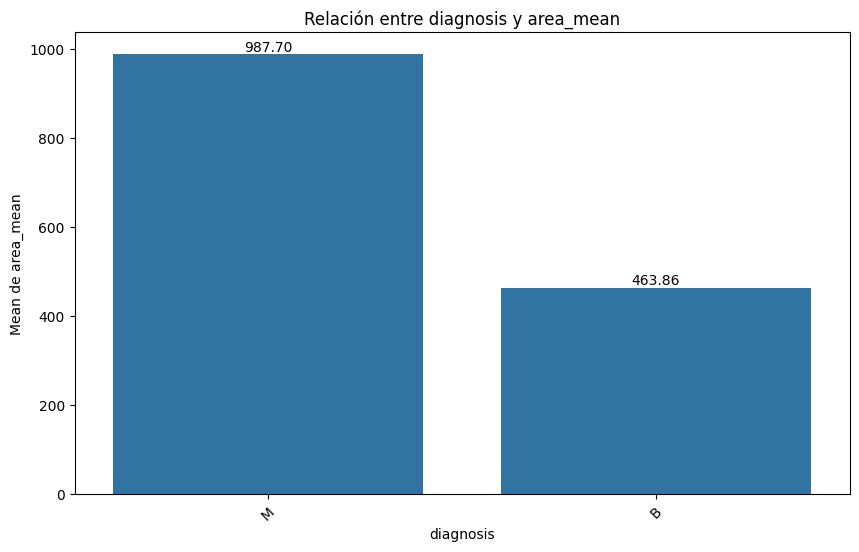

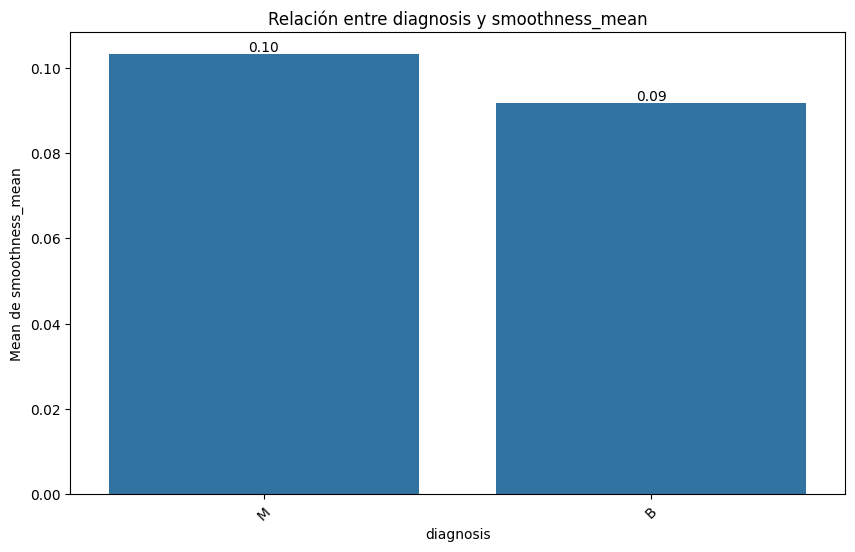

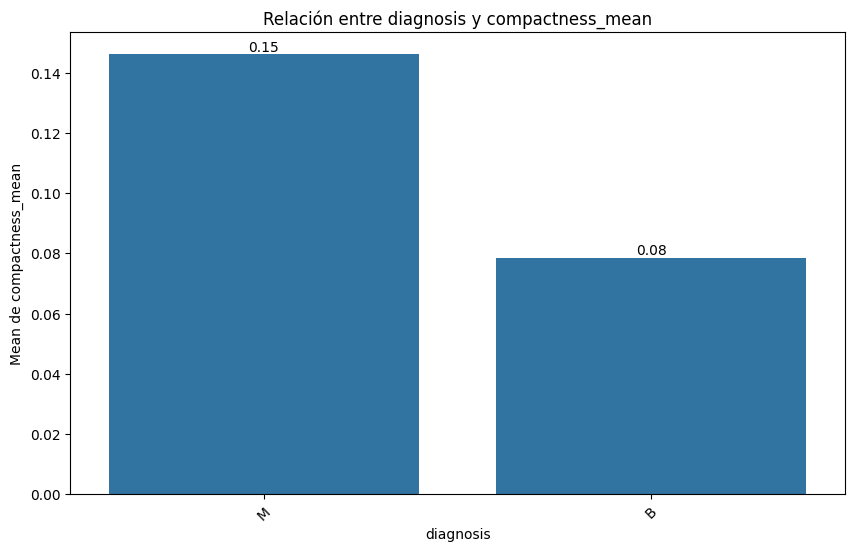

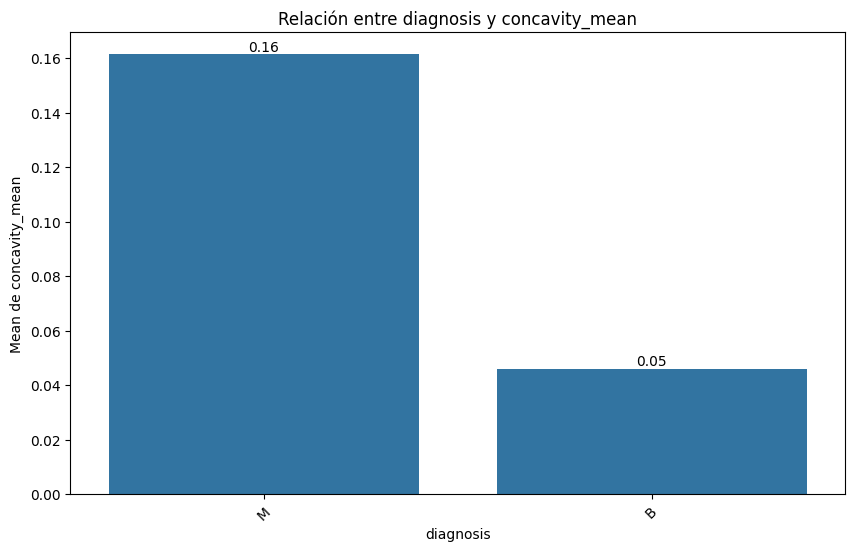

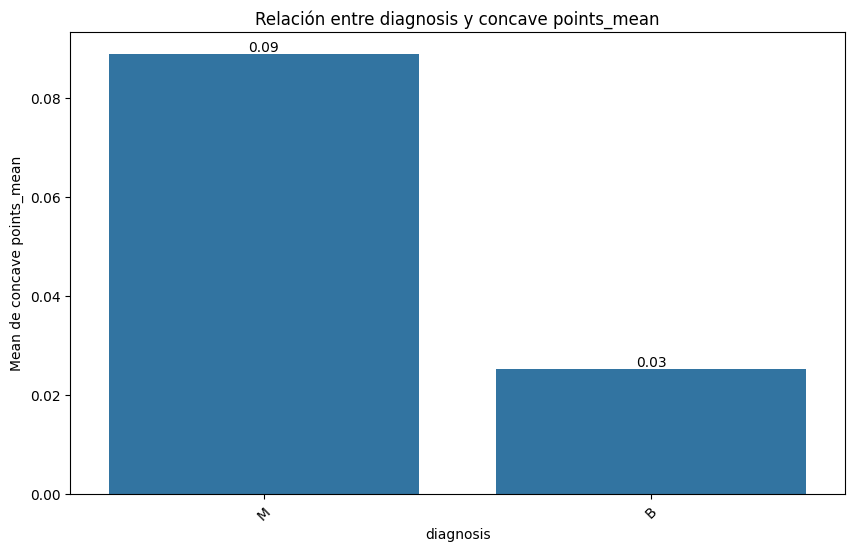

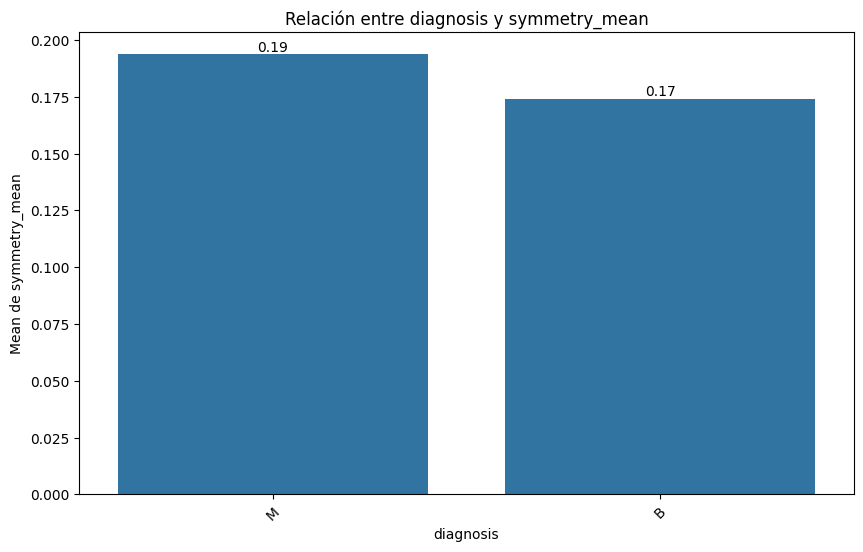

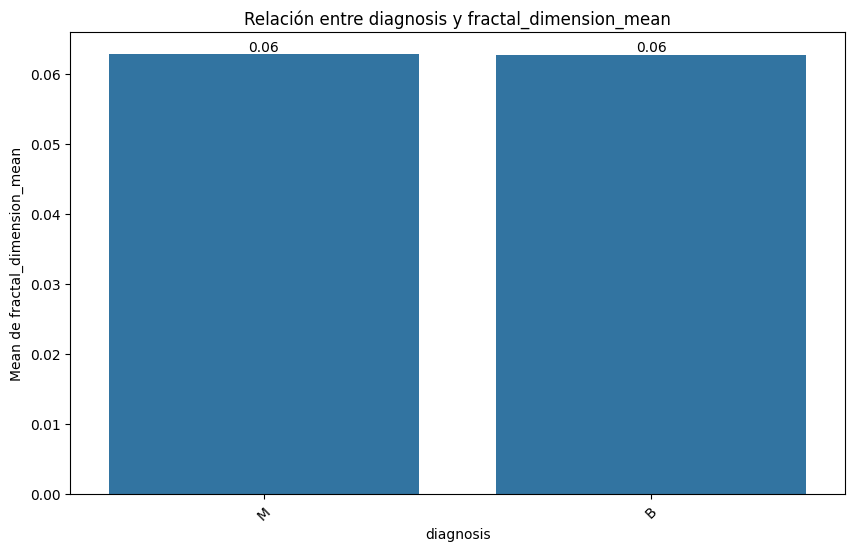

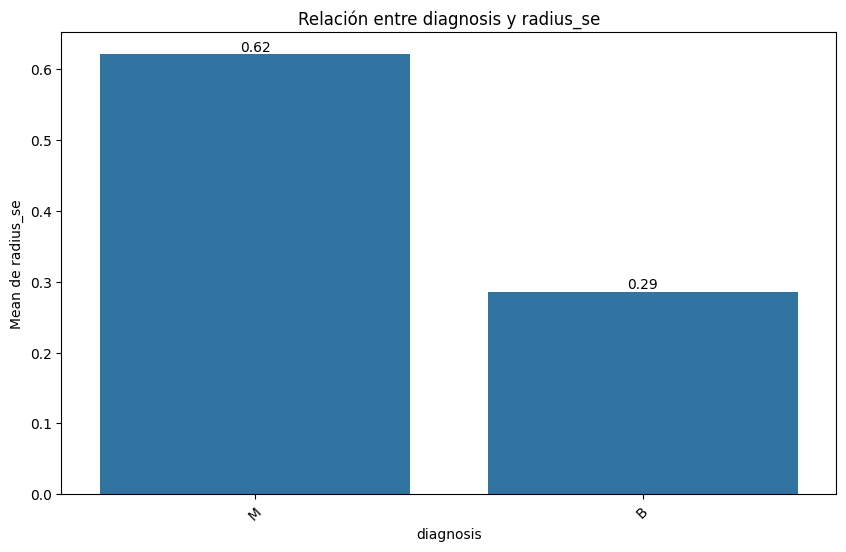

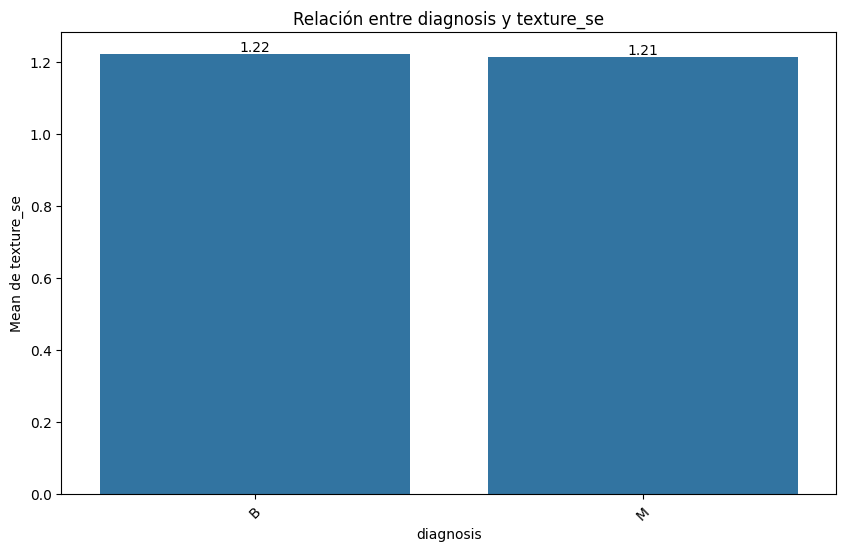

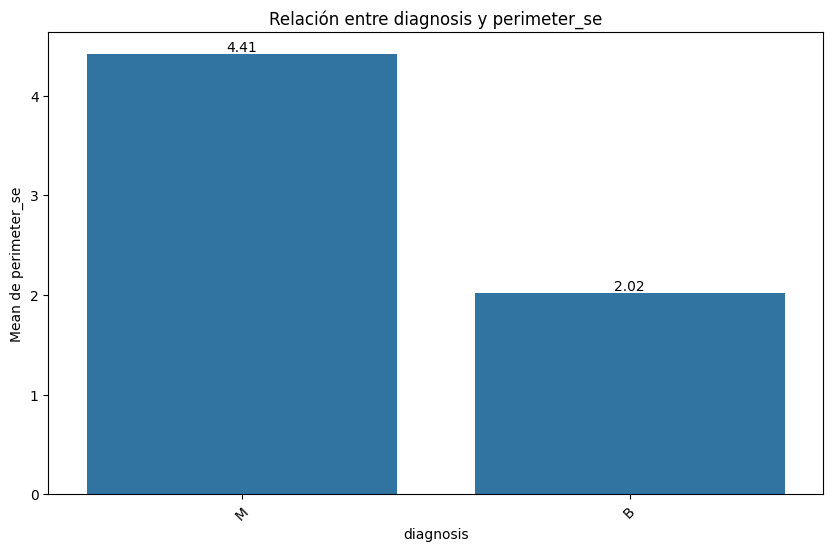

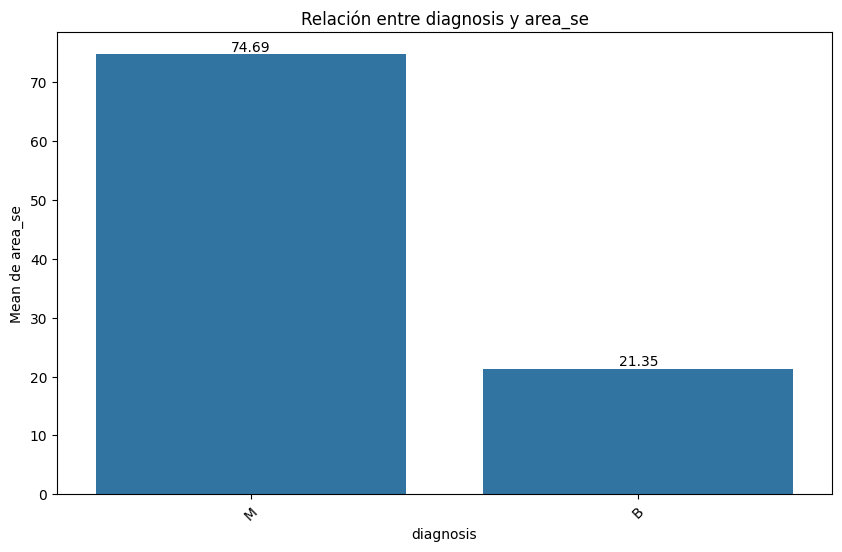

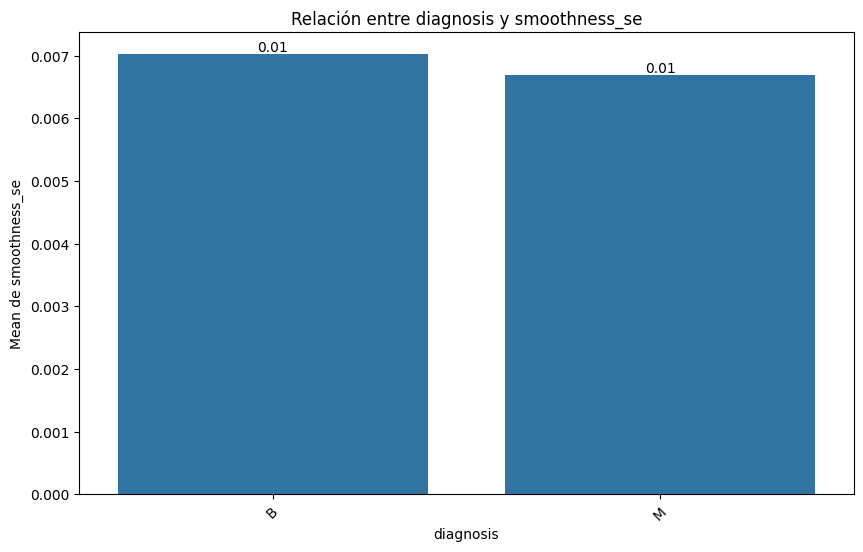

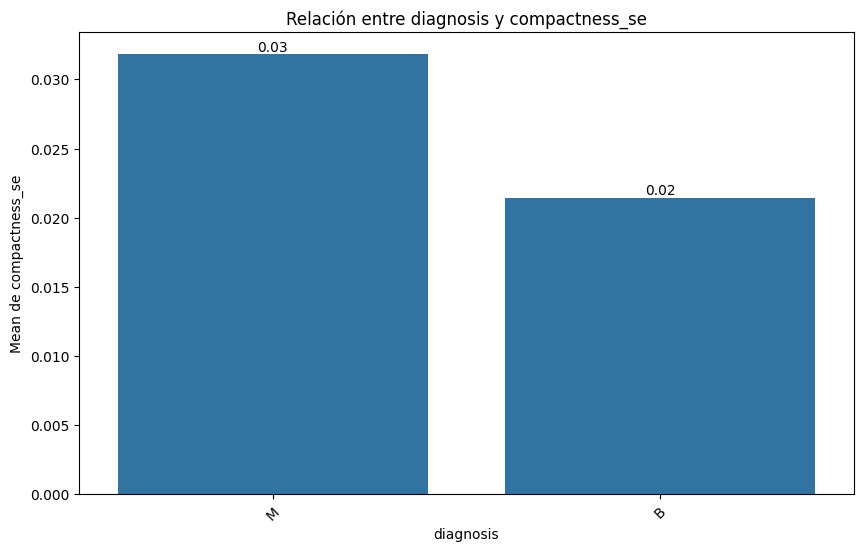

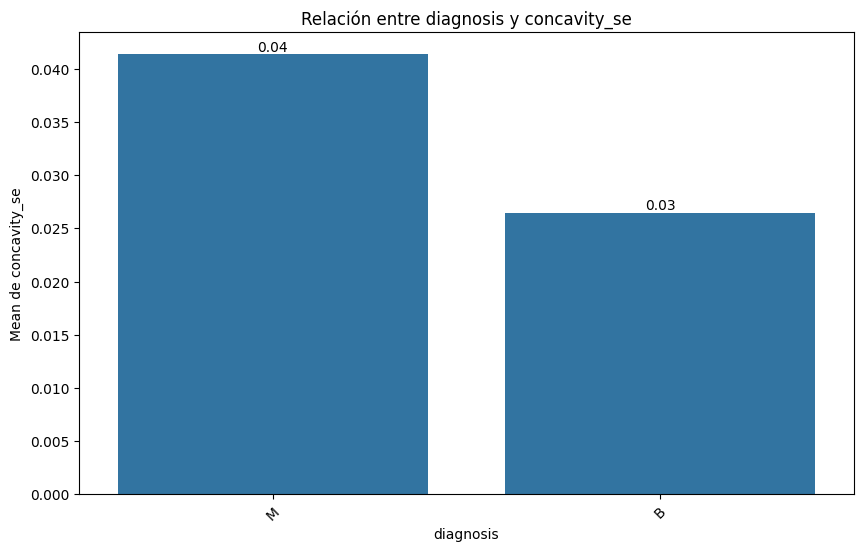

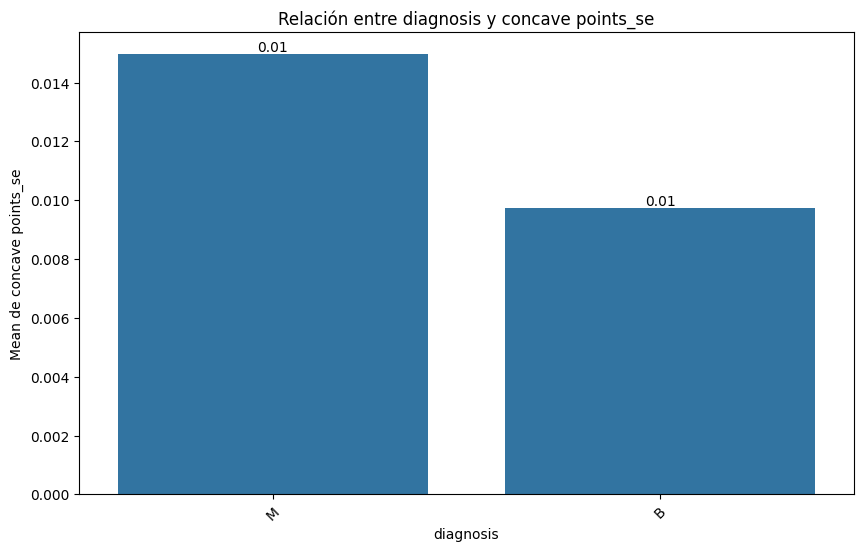

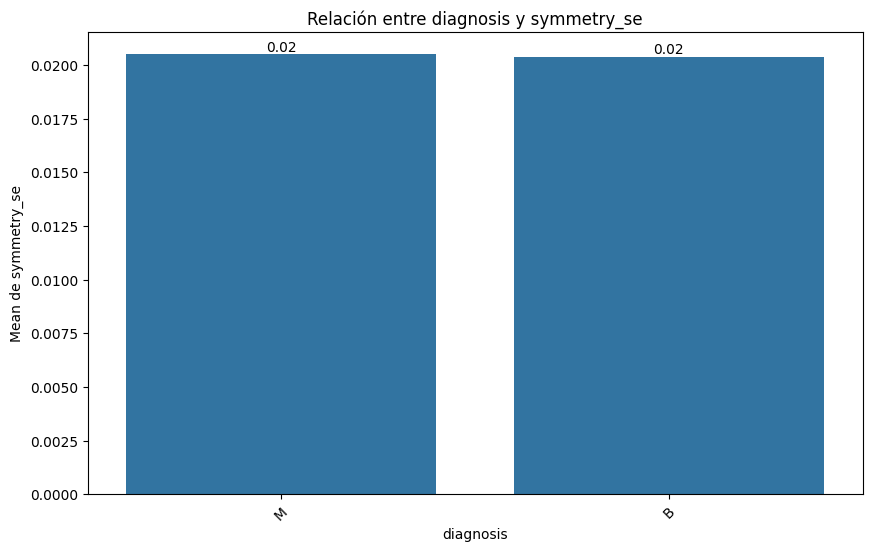

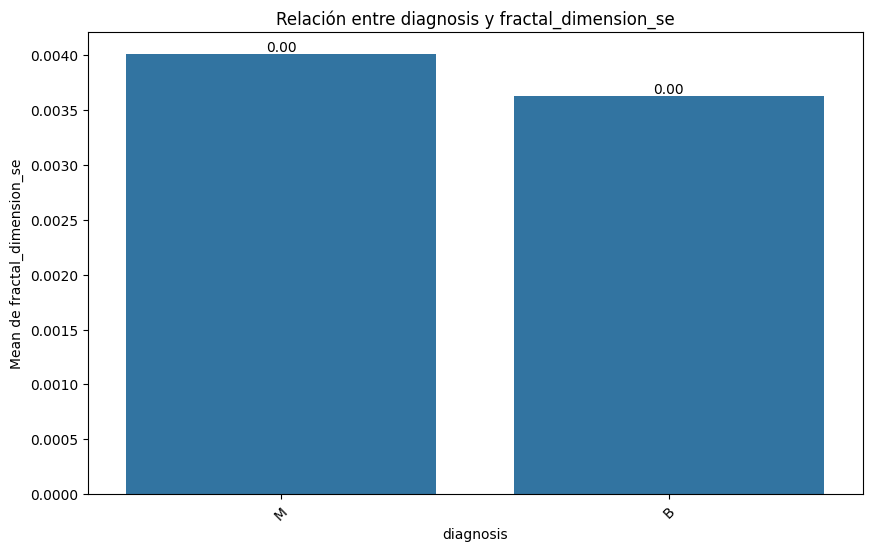

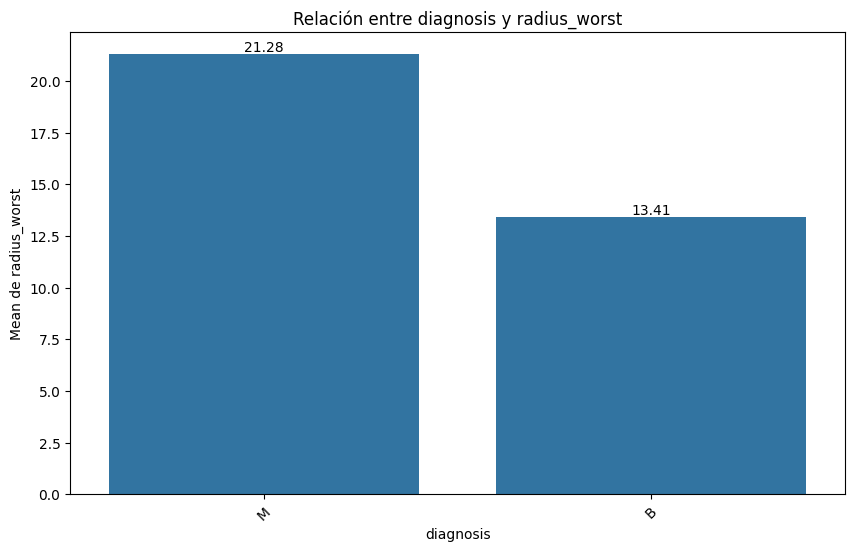

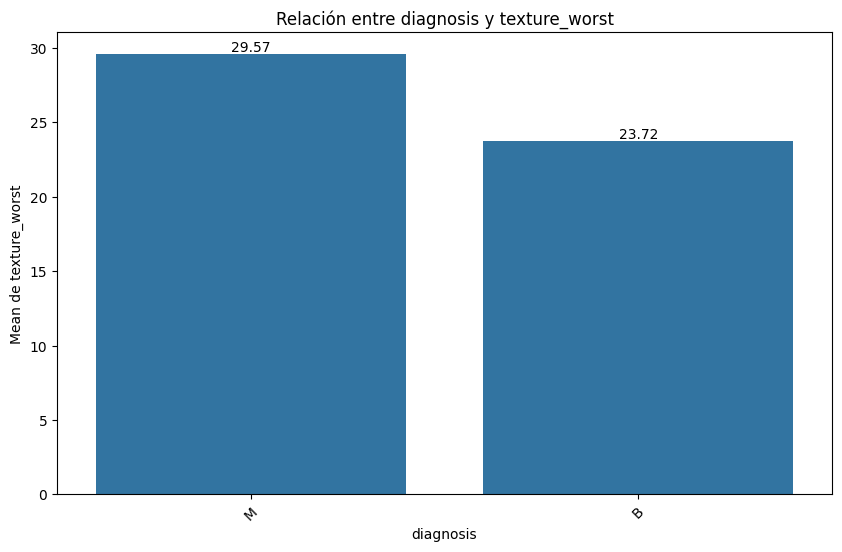

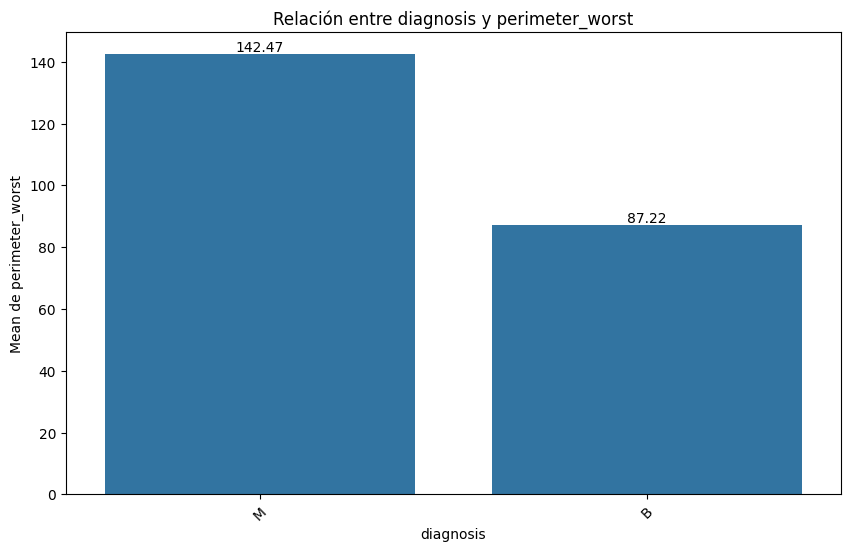

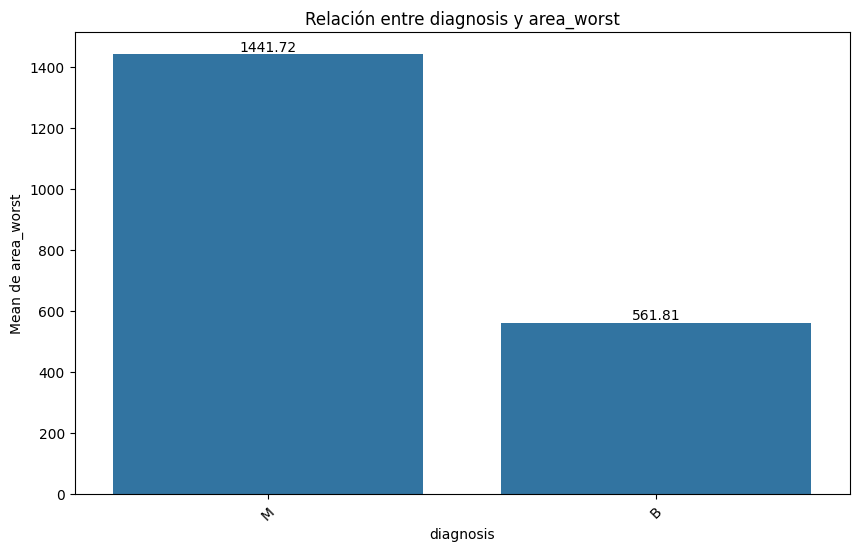

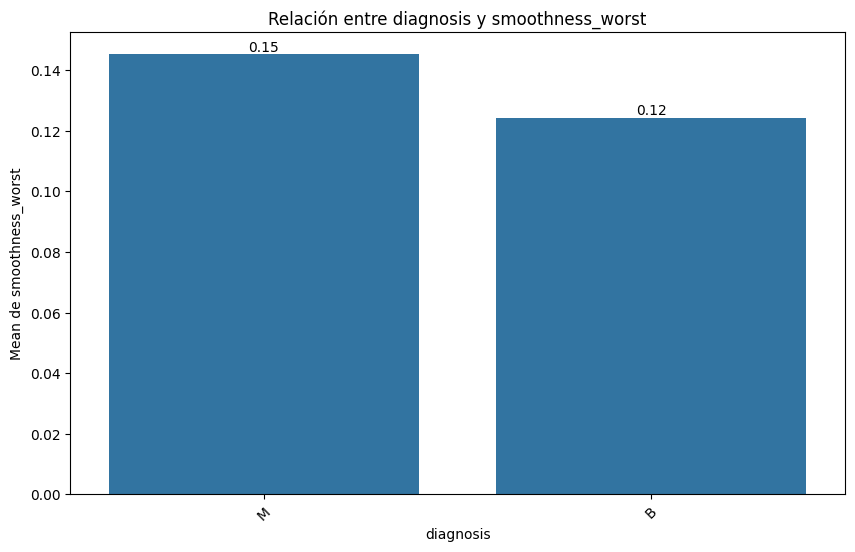

In [14]:
# bt.plot_categorical_numerical_relationship(train_set,"diagnosis",train_copi.columns,show_values=True )
# Está mal solo puede ser una columna categórica y una columna numérica.
# Hay que hacer un bucle:

columnas_num = [col for col in train_set if col != "diagnosis"] # primero preparo la lista de columnas.
for col in columnas_num:
    bt.plot_categorical_numerical_relationship(train_set, "diagnosis", col, show_values=True)


In [15]:
df.corr(numeric_only=True)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,0.559837,0.446630,0.341198,0.345007,0.688132,-0.253691,-0.051269,-0.205151,-0.231854,0.504942


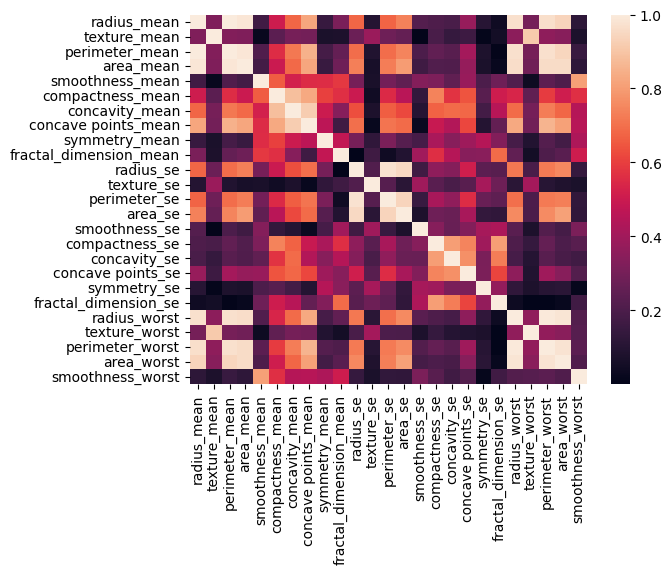

In [16]:
sns.heatmap(np.abs(df.corr(numeric_only=True)));

Por lo que se ve las variables tienen una fuerte correlación entre ellas. Sobre todo los diferentes perimeter_, area_ y radius_.

### Ejercicio 6: MiniEDA (III)

Crea una variable de tipo lista a la que asignes los valores de las columnas que creas conveniente emplear como features en función de lo visto en el miniEDA. Haz una lista de modelos/algoritmos que vas a emplear para hacer el modelo (solo los nombres). En función de la lista anterior, ¿tienes que tratar las variables, por qué?

In [17]:
train_set.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst'],
      dtype='object')

In [18]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst']

Excluyo 'fractal_dimension_mean' y 'symmetry_se' porque tienen la misma proporción en M y B.

In [19]:
print(train_set[features].describe().T)

                      count        mean         std         min         25%  \
radius_mean           455.0   14.166077    3.579081    6.981000   11.710000   
texture_mean          455.0   19.417692    4.290653    9.710000   16.335000   
perimeter_mean        455.0   92.215868   24.717118   43.790000   75.235000   
area_mean             455.0  659.578242  360.418686  143.500000  420.400000   
smoothness_mean       455.0    0.095993    0.014310    0.062510    0.085130   
compactness_mean      455.0    0.103835    0.053910    0.019380    0.063735   
concavity_mean        455.0    0.089184    0.081698    0.000000    0.029520   
concave points_mean   455.0    0.049015    0.039686    0.000000    0.019685   
symmetry_mean         455.0    0.181497    0.027646    0.106000    0.162050   
radius_se             455.0    0.411187    0.290183    0.111500    0.233650   
texture_se            455.0    1.217882    0.552312    0.360200    0.841800   
perimeter_se          455.0    2.911569    2.123119 

"RandomForestClassifier", "XGBClassifier", "LGBMClassifier".  
Si tenemos que tratar las features numéricas, en este caso todas.

### Ejercicio 7: Tratamiento de features

Trata las features de manera que puedan ser empleadas por los modelos que escogiste en el ejercicio anterior. Recuerda que este es un paso necesario porque los modelos no entienden de primeras de "letras" (salvo alguno que no es que entienda sino que hace sus transformaciones por dentro) y porque en determinados algoritmos es necesario que los rangos de las features estén escalados para que el algoritmo no se decante (érroneamente) por alguna feature sólo porque sus valores son mayores en rango que el de otras. NOTA: Recuerda que lo que le hagas al train, se lo tienes que hacer al test

In [20]:
# Después de ver en kaggle que las variables tienen forma sesgada en sus histogramas, 
# voy transformarlas mediante log1p (porque algunas variables tienen el valor 0) a forma normal,
#  los datos a distribución gaussiana.
train_set[features] = np.log1p(train_set[features]) 

# Lo mismo para test
test_set[features] = np.log1p(test_set[features])

In [21]:
# Normalizar columnas (escalar)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_set[features] = scaler.fit_transform(train_set[features])

# Lo mismo para test
test_set[features] = scaler.transform(test_set[features])

print(train_set[features].describe())

        radius_mean  texture_mean  perimeter_mean     area_mean  \
count  4.550000e+02  4.550000e+02    4.550000e+02  4.550000e+02   
mean  -1.046294e-15  2.732857e-16    6.109887e-16 -5.465713e-17   
std    1.001101e+00  1.001101e+00    1.001101e+00  1.001101e+00   
min   -2.750081e+00 -3.003224e+00   -2.795370e+00 -2.875647e+00   
25%   -6.733907e-01 -6.843431e-01   -6.734523e-01 -6.717534e-01   
50%   -1.348832e-01 -1.984784e-02   -1.382034e-01 -1.330904e-01   
75%    6.073694e-01  6.415821e-01    6.227877e-01  6.391723e-01   
max    3.024963e+00  3.375700e+00    2.959533e+00  2.996100e+00   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count     4.550000e+02      4.550000e+02    4.550000e+02         4.550000e+02   
mean      1.184889e-15     -2.518132e-16    2.908540e-16        -4.001683e-17   
std       1.001101e+00      1.001101e+00    1.001101e+00         1.001101e+00   
min      -2.380751e+00     -1.652318e+00   -1.157209e+00        -1.27407

In [30]:
train_set["diagnosis"] = train_set["diagnosis"].map({"B":0 , "M":1})
test_set["diagnosis"] = test_set["diagnosis"].map({"B":0 , "M":1})

### Ejercicio 8: Creación de los dataset de train y test

Crea las parejas X,y de train y test.

In [ ]:
X_train = train_set[features]
y_train = train_set[target].values.ravel()
X_test = test_set[features]
y_test= test_set[target].values.ravel()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(455, 23)
(455,)
(114, 23)
(114,)


In [52]:
print(X_train[features].describe())

        radius_mean  texture_mean  perimeter_mean     area_mean  \
count  4.550000e+02  4.550000e+02    4.550000e+02  4.550000e+02   
mean  -1.046294e-15  2.732857e-16    6.109887e-16 -5.465713e-17   
std    1.001101e+00  1.001101e+00    1.001101e+00  1.001101e+00   
min   -2.750081e+00 -3.003224e+00   -2.795370e+00 -2.875647e+00   
25%   -6.733907e-01 -6.843431e-01   -6.734523e-01 -6.717534e-01   
50%   -1.348832e-01 -1.984784e-02   -1.382034e-01 -1.330904e-01   
75%    6.073694e-01  6.415821e-01    6.227877e-01  6.391723e-01   
max    3.024963e+00  3.375700e+00    2.959533e+00  2.996100e+00   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count     4.550000e+02      4.550000e+02    4.550000e+02         4.550000e+02   
mean      1.184889e-15     -2.518132e-16    2.908540e-16        -4.001683e-17   
std       1.001101e+00      1.001101e+00    1.001101e+00         1.001101e+00   
min      -2.380751e+00     -1.652318e+00   -1.157209e+00        -1.27407

In [41]:
y_train[0:5]

array([1, 0, 0, 1, 1])

### Ejercicio 9: Instanciación de modelos

Importa e instancia los modelos que hayas escogido en el ejercicio 6. En general, no hace falta que asignes ahora ningún hiperparámetro salvo en los basados en árboles en los que debes escoger un max_depth para evitar el sobreajuste inicial. Si quieres emplear la regresión logística es posible que tengas que utilizar un valor de max_iter para que el algoritmo converja.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
  # from lightgbm import LGBMClassifier
import xgboost
from sklearn.svm import SVC


log_reg = LogisticRegression(max_iter=1000, random_state=42)
rfc = RandomForestClassifier(max_depth=5, random_state=42)
# lgbmc = LGBMClassifier(random_state=42)
xgbc = xgboost.XGBClassifier(random_state= 42)
svm = SVC(kernel='rbf', random_state=42) 

No voy a usar LGBMClassifier, me da problemas con tan pocos datos.  
El kernel RBF (Radial Basis Function) es el más flexible y se adapta a relaciones no lineales entre las features.

### Ejercicio 10: Comparativa de modelos

Haz la comparativa de modelos empleando cross_val_score (es decir la validación cruzada). Utiliza k = 5, y un scoring acorde a la métrica escogida en el ejercicio 1. Si no tienes clara la métrica entonces emplea el recall_medio y usa scoring = "balanced acuracy". Escoge el modelo ganador.

"Alto nivel de acierto en detectar quien puede desarrollar el cancer" Es un problema de clasificación binaría.    
Para comparar modelos cross_val_score.  
scoring para los modelos: "balanced_accuracy", "recall", "f1".  
(scorers =["balanced_accuracy", "recall", "f1"]). Los resultados estarán en results con claves como 'test_balanced_accuracy', 'test_recall', etc.  
Métricas a utilizar classification_report y confusion_matrix.


In [44]:
model_names = ["LogisticRegression","RandomForestClassifier", "XGBClassifier", "SVC"]
model_set = [log_reg, rfc, xgbc, svm]
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(type(modelo).__name__)
    metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy", verbose= 0)
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

LogisticRegression
RandomForestClassifier
XGBClassifier
SVC


In [ ]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, balanced_accuracy: {valores}")
print(f"El ganador es {ganador}")

Model <LogisticRegression>, balanced_accuracy: [0.97058824 0.97652219 0.95588235 0.97652219 0.95304438]
Model <RandomForestClassifier>, balanced_accuracy: [0.98529412 0.98529412 0.90892673 0.94711042 0.94427245]
Model <XGBClassifier>, balanced_accuracy: [0.95588235 0.98529412 0.93833849 0.98529412 0.92956656]
Model <SVC>, balanced_accuracy: [0.95588235 1.         0.94117647 0.96775026 0.97652219]
El ganador es SVC


### Ejercicio 11: Ajuste de hiperparámetros

Escoge un grid para ajustar los hiperparámetros de tu modelo. Crea un objeto GridSearch y "ajustalo" (emplea su método fit) para encontrar la mejor combinaciónde hiperparámetros empleando la métrica que decidimos en el ejercio 1. Si no lo tienes claro emplea "balance accuracy". Por otro lado, incluye en el grid, el hiperparámetro que permita que el modelo "compense" el desbalanceo del dataset de entrada, aunque este no lo tenga.

In [53]:
from sklearn.model_selection import GridSearchCV
scorers =["balanced_accuracy", "recall", "f1"]
svm = SVC(random_state=42)
params_grid = {
    "C": [1,2,3],
    "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
    "degree": [3,6,9],
    "class_weight": ["balanced"],
    "max_iter": [1000, 1500, 2000]    
}

grid_svm= GridSearchCV( svm,
                       param_grid= params_grid,
                       cv =5, 
                       scoring= scorers,
                       refit= "recall",
                       return_train_score= True,
                       n_jobs= -1,
                       verbose=0)

grid_svm.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 2, ...], 'class_weight': ['balanced'], 'degree': [3, 6, ...], 'kernel': ['linear', 'poly', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['balanced_accuracy', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [57]:
print(grid_svm.best_estimator_)
print(grid_svm.best_params_)
print("Mejor Recall:",grid_svm.best_score_)

SVC(C=2, class_weight='balanced', max_iter=1000, random_state=42)
{'C': 2, 'class_weight': 'balanced', 'degree': 3, 'kernel': 'rbf', 'max_iter': 1000}
Mejor Recall: 0.9647058823529411


### Ejercicio 12: Evaluación del modelo

Evalúa el modelo contra el dataset de test. Muestra el informe de clasificación y haz una valoración de si el hospital aceptaría el modelo o no.

In [58]:
y_pred = grid_svm.best_estimator_.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Ejercicio 13: Análisis de errores

Muestra la matriz de confusión con los porcentajes de precisión (emplea ConfusionMatrixDisplay.from_predictions con el argumento normalize con el valor adecuado). Haz un pequeño análisis.

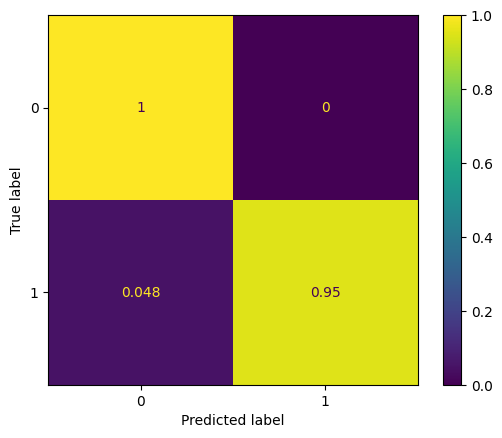

In [59]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize= "true");

### EXTRA: 

Busca en Internet o pregúntale a tu AI preferida, cómo se graba un modelo en disco y gúardalo en "./models/cancer_pred" con la extesión apropiada.

In [60]:
import os
os.makedirs('./models', exist_ok=True)  # Crea la carpeta si no existe

In [61]:
import joblib
joblib.dump({
    'model': grid_svm,
    'scaler': scaler,
    'features': features,
    'preprocessing': {'log1p': True},
    'best_params': grid_svm.best_params_
}, './models/cancer_pred.pkl.gz', compress=3)

['./models/cancer_pred.pkl.gz']

**pkl.gz** = Pickle comprimido con gzip  
Es la combinación de dos extensiones:    
.pkl = Pickle    
Formato de serialización de Python  
Convierte objetos Python en bytes para guardarlos  
.gz = Gzip  
Algoritmo de compresión  
Reduce el tamaño del archivo  
Para modelos de ML, .pkl.gz con compress=3 es la opción estándar.

In [62]:
# Carga
saved = joblib.load('./models/cancer_pred.pkl.gz')

In [63]:
saved

{'model': GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
              param_grid={'C': [1, 2, 3], 'class_weight': ['balanced'],
                          'degree': [3, 6, 9],
                          'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
                          'max_iter': [1000, 1500, 2000]},
              refit='recall', return_train_score=True,
              scoring=['balanced_accuracy', 'recall', 'f1']),
 'scaler': StandardScaler(),
 'features': ['radius_mean',
  'texture_mean',
  'perimeter_mean',
  'area_mean',
  'smoothness_mean',
  'compactness_mean',
  'concavity_mean',
  'concave points_mean',
  'symmetry_mean',
  'radius_se',
  'texture_se',
  'perimeter_se',
  'area_se',
  'smoothness_se',
  'compactness_se',
  'concavity_se',
  'concave points_se',
  'fractal_dimension_se',
  'radius_worst',
  'texture_worst',
  'perimeter_worst',
  'area_worst',
  'smoothness_worst'],
 'preprocessing': {'log1p': True},
 'best_params': {'C': 2,
  'class_weight'